# 1- Introduction


#  2- Importation des données


In [102]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import pipeline, AutoTokenizer, DistilBertTokenizer, DistilBertForSequenceClassification
from sentence_transformers import SentenceTransformer
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from wordcloud import WordCloud
import ast
from tqdm import tqdm
import spacy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import trim_mean, norm
from scipy import stats
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
# Load the IMDb dataset
import kagglehub
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
imdb_df = pd.read_csv(f"{dataset_path}/IMDB Dataset.csv")

100%|██████████| 25.7M/25.7M [00:00<00:00, 176MB/s]

Extracting files...


In [3]:
# Display basic information
print("Dataset Shape:", imdb_df.shape)
print("\n")

print("First few rows:")
display(imdb_df.head())
print("\n")

print("Dataset Info:")
print(imdb_df.info())
print("\n")

Dataset Shape: (50000, 2)


First few rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None




##### Detection of Missing Values


columns with missing values:
[]




<Axes: title={'center': 'Plot bar chart of the number of missing values for each attribute'}>

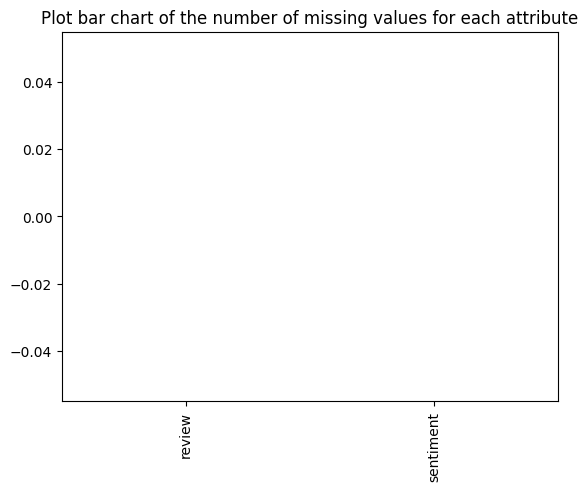

In [4]:
# count missing value for each column
missing_values_count = imdb_df.isnull().sum()
na_columns = list(missing_values_count[missing_values_count>0].index.values)

# print columns with missing values
print("columns with missing values:")
print(na_columns)
print("\n")

#Affichage des colonnes avec le nombre de missing values en plot bar
missing_values_count.plot(kind = "bar", title="Plot bar chart of the number of missing values for each attribute")

##### Exploration of Unique Values in the Dataset  
This step allows us to examine the different unique values in the dataset for each column. If there are any non-unique values, we can merge them.

In [5]:
# Traitement des colonnes spécifiques

# 1. redundent values detection for "review" column
review_value_counts = imdb_df["review"].value_counts()
redundant_review = review_value_counts[review_value_counts > 1]

if not redundant_review.empty:
    print("Column 'review' redundant values:")
    for value, count in redundant_review.items():
        # Truncate long text to show only the first 30 characters
        if isinstance(value, str) and len(value) > 30:
            truncated_value = value[:30] + "..."
        else:
            truncated_value = value
        print(f"  {truncated_value} (appears {count} times)")
        print()
    print()
else:
    print("Column 'review' has no redundant values.\n")


Column 'review' redundant values:
  Loved today's show!!! It was a... (appears 5 times)

  Hilarious, clean, light-hearte... (appears 4 times)

  How has this piece of crap sta... (appears 3 times)

  Nickelodeon has gone down the ... (appears 3 times)

  You do realize that you've bee... (appears 3 times)

  This show comes up with intere... (appears 3 times)

  I see that C. Thomas Howell ha... (appears 3 times)

  When i got this movie free fro... (appears 3 times)

  Robert Jordan is a television ... (appears 3 times)

  A talented high school graduat... (appears 2 times)

  Ill-conceived sequel(..the abs... (appears 2 times)

  This movie was physically pain... (appears 2 times)

  What was an exciting and fairl... (appears 2 times)

  Wow! So much fun! Probably a b... (appears 2 times)

  One of Disney's best films tha... (appears 2 times)

  "Go Fish" garnered Rose Troche... (appears 2 times)

  An Epic Story of Hope constrai... (appears 2 times)

  I'm gonna tip the scales here

In [6]:
# 2. "sentiment" column (unique values):
unique_sentiment = imdb_df["sentiment"].unique()
print(f"Column 'sentiment' unique values: {unique_sentiment}\n")

Column 'sentiment' unique values: ['positive' 'negative']



#  3- Understanding the Data

# 3.1. review word count statistics

In [7]:
# Calculate word review length statistics
word_count = imdb_df['review'].apply(lambda x: len(x.split()))

## 3.1.1 Measures of Central Tendency

##### mean:

In [8]:
word_count_mean = word_count.mean()
print(f"Mean: {word_count_mean:.2f}")

Mean: 231.16


##### median

In [9]:
word_count_median = word_count.median()
print(f"Median: {word_count_median:.2f}")

Median: 173.00


##### mode

In [10]:
word_count_mode = word_count.mode()[0]
print(f"Mode: {word_count_mode:.2f}")

Mode: 127.00


##### max

In [11]:
word_count_max_value = word_count.max()
print(f"Max: {word_count_max_value:.2f}")

Max: 2470.00


##### min

In [12]:
word_count_min_value = word_count.min()
print(f"Min: {word_count_min_value:.2f}")

Min: 4.00


##### Gaussian distribution

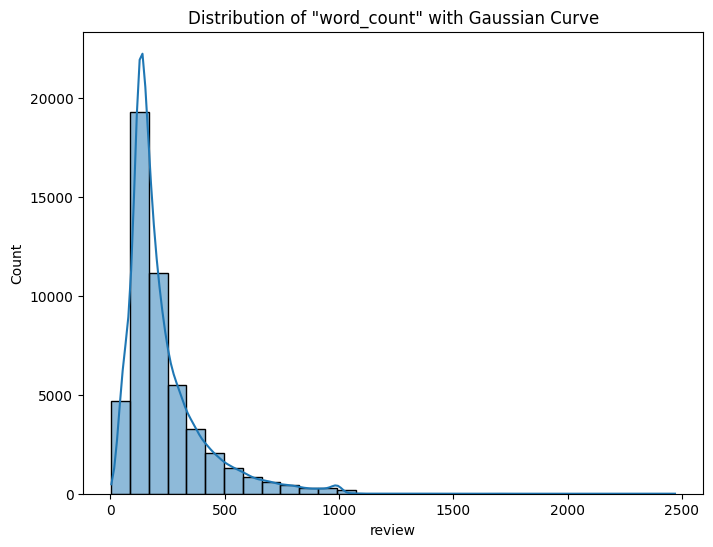

In [13]:
# Histogram with Gaussian Distribution
plt.figure(figsize=(8, 6))
sns.histplot(word_count, kde=True, bins=30)
plt.title(f'Distribution of "word_count" with Gaussian Curve')
plt.show()

## 3.1.2 Measures of Data Dispersion

#### Quartiles and outliers detection

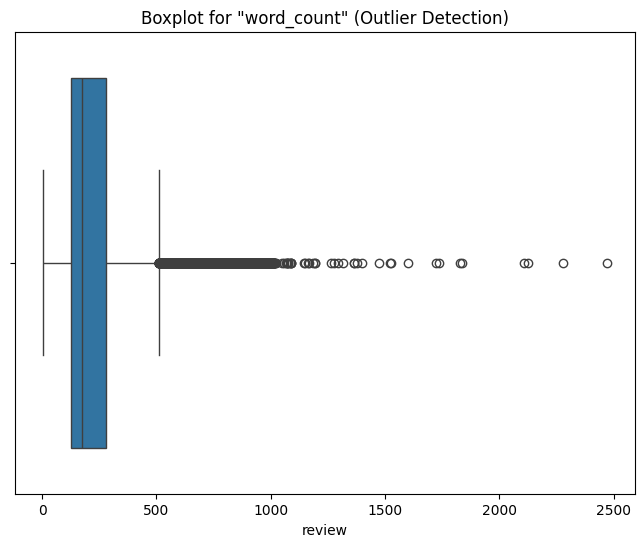

In [14]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=word_count)
plt.title(f'Boxplot for "word_count" (Outlier Detection)')
plt.show()

#### Quantiles

In [15]:
word_count_quartiles = word_count.quantile([0.25, 0.5, 0.75])
print(f"\nQuartiles:\n{word_count_quartiles}")


Quartiles:
0.25    126.0
0.50    173.0
0.75    280.0
Name: review, dtype: float64


#### Variance and standard deviation

In [16]:
word_count_variance = word_count.var()
word_count_std_dev = word_count.std()
print(f"Variance: {word_count_variance:.2f}")
print(f"Standard Deviation: {word_count_std_dev:.2f}")

Variance: 29358.77
Standard Deviation: 171.34


## 3.1.3. Per Sentiments statistics

In [17]:
# Separate positive and negative reviews
positive_reviews = ' '.join(imdb_df[imdb_df['sentiment'] == 'positive']['review'])
negative_reviews = ' '.join(imdb_df[imdb_df['sentiment'] == 'negative']['review'])

##### Word cloud

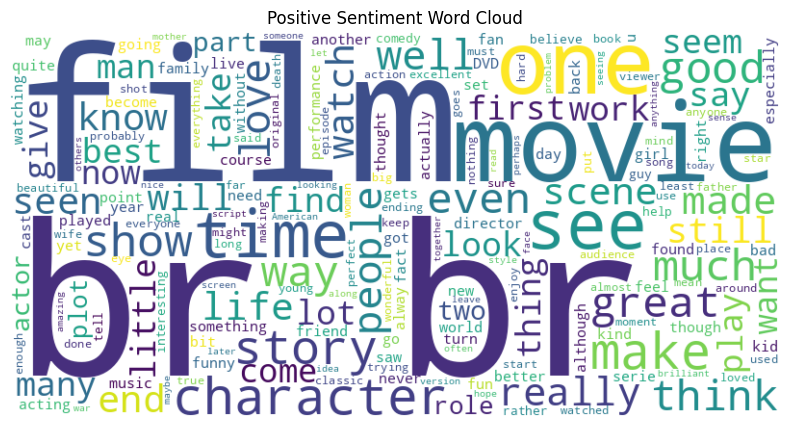

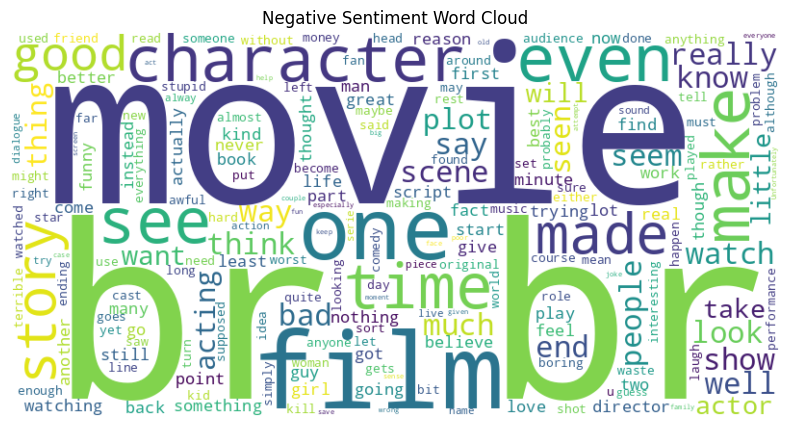

In [18]:
# Function to generate word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds
generate_word_cloud(positive_reviews, 'Positive Sentiment Word Cloud')
print()

generate_word_cloud(negative_reviews, 'Negative Sentiment Word Cloud')

##### Top 15 words per sentiment

In [19]:
# Function to get top n words
def get_top_n_words(review, n=10):
    words = review.split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

# Get top 10 words
top_10_positive = get_top_n_words(positive_reviews)
top_10_negative = get_top_n_words(negative_reviews)

print("Top 10 words in positive sentiment:")
display(top_10_positive)
print()

print("Top 10 words in negative sentiment:")
display(top_10_negative)
print()


Top 10 words in positive sentiment:


[('the', 291927),
 ('and', 165943),
 ('a', 155775),
 ('of', 149178),
 ('to', 128343),
 ('is', 108168),
 ('in', 90427),
 ('that', 62449),
 ('I', 62223),
 ('it', 53378)]


Top 10 words in negative sentiment:


[('the', 276808),
 ('a', 151185),
 ('and', 135976),
 ('of', 134447),
 ('to', 133507),
 ('is', 94888),
 ('in', 79554),
 ('I', 70275),
 ('that', 64369),
 ('this', 62112)]

##### Average word counts per sentiment

In [20]:
# Function to calculate average review length and word count
def calculate_averages(df, sentiment):
    sentiment_df = df[df['sentiment'] == sentiment]
    avg_word_count = sentiment_df['review'].apply(lambda x: len(x.split())).mean()
    return avg_word_count


# Calculate averages
avg_word_count_positive = calculate_averages(imdb_df, 'positive')
avg_word_count_negative = calculate_averages(imdb_df, 'negative')


print(f"Average word count of a review for positive sentiment: {avg_word_count_positive:.2f}")
print(f"Average word count of a review for negative sentiment: {avg_word_count_negative:.2f}")

Average word count of a review for positive sentiment: 232.85
Average word count of a review for negative sentiment: 229.46


# 3.2. review length statistics

In [21]:
# Calculate word review length statistics
review_length = imdb_df['review'].apply(len)

## 3.2.1 Measures of Central Tendency

##### mean:

In [22]:
review_length_mean = review_length.mean()
print(f"Mean: {review_length_mean:.2f}")

Mean: 1309.43


##### median

In [23]:
review_length_median = review_length.median()
print(f"Median: {review_length_median:.2f}")

Median: 970.00


##### mode

In [24]:
review_length_mode = review_length.mode()[0]
print(f"Mode: {review_length_mode:.2f}")

Mode: 658.00


##### max

In [25]:
review_length_max_value = review_length.max()
print(f"Max: {review_length_max_value:.2f}")

Max: 13704.00


##### min

In [26]:
review_length_min_value = review_length.min()
print(f"Min: {review_length_min_value:.2f}")

Min: 32.00


##### Gaussian distribution

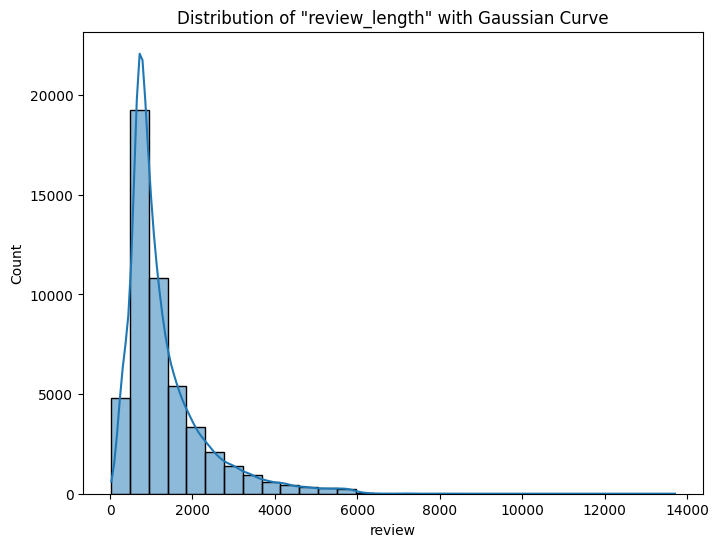

In [27]:
# Histogram with Gaussian Distribution
plt.figure(figsize=(8, 6))
sns.histplot(review_length, kde=True, bins=30)
plt.title(f'Distribution of "review_length" with Gaussian Curve')
plt.show()

## 3.2.2 Measures of Data Dispersion

#### Quartiles and outliers detection

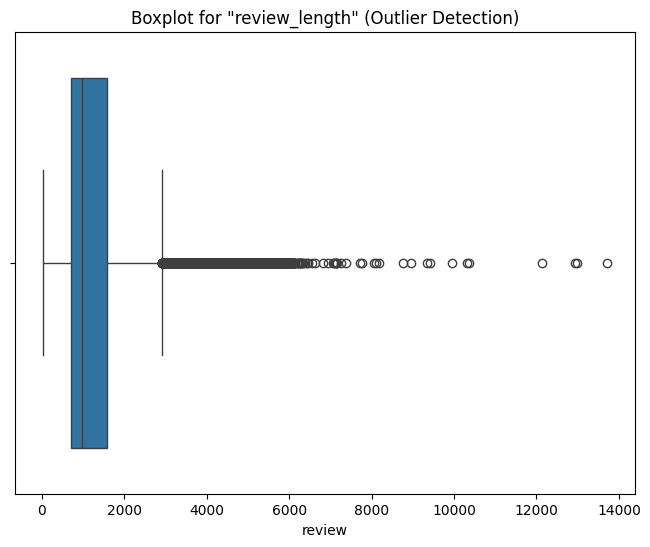

In [28]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=review_length)
plt.title(f'Boxplot for "review_length" (Outlier Detection)')
plt.show()

#### Quantiles

In [29]:
review_length_quartiles = review_length.quantile([0.25, 0.5, 0.75])
print(f"\nQuartiles:\n{review_length_quartiles}")


Quartiles:
0.25     699.00
0.50     970.00
0.75    1590.25
Name: review, dtype: float64


#### Variance and standard deviation

In [30]:
review_length_variance = review_length.var()
review_length_std_dev = review_length.std()
print(f"Variance: {review_length_variance:.2f}")
print(f"Standard Deviation: {review_length_std_dev:.2f}")

Variance: 979561.54
Standard Deviation: 989.73


## 3.2.3. Per Sentiments statistics

In [31]:
# Separate positive and negative reviews
positive_reviews = ' '.join(imdb_df[imdb_df['sentiment'] == 'positive']['review'])
negative_reviews = ' '.join(imdb_df[imdb_df['sentiment'] == 'negative']['review'])

##### Average review length per sentiment

In [32]:
# Function to calculate average review length and word count
def calculate_averages(df, sentiment):
    sentiment_df = df[df['sentiment'] == sentiment]
    avg_review_length = sentiment_df['review'].apply(len).mean()
    return avg_review_length


# Calculate averages
avg_review_length_positive = calculate_averages(imdb_df, 'positive')
avg_review_length_negative = calculate_averages(imdb_df, 'negative')


print(f"Average word count of a review for positive sentiment: {avg_review_length_positive:.2f}")
print(f"Average word count of a review for negative sentiment: {avg_review_length_negative:.2f}")

Average word count of a review for positive sentiment: 1324.80
Average word count of a review for negative sentiment: 1294.06


# 4. Data pre-processing

## 4.1 Data cleaning

4.1.1. Duplicates

In [33]:
# Remove duplicates based on the "review" column
imdb_df_cleaned_from_duplicates = imdb_df.drop_duplicates(subset=["review"])

# Check if duplicates are removed
review_value_counts_cleaned = imdb_df_cleaned_from_duplicates["review"].value_counts()
redundant_review_cleaned = review_value_counts_cleaned[review_value_counts_cleaned > 1]

if not redundant_review_cleaned.empty:
    print("Column 'review' still has redundant values after cleaning:")
    for value, count in redundant_review_cleaned.items():
        if isinstance(value, str) and len(value) > 30:
            truncated_value = value[:30] + "..."
        else:
            truncated_value = value
        print(f"  {truncated_value} (appears {count} times)")
        print()
    print()
else:
    print("Column 'review' has no redundant values after cleaning.\n")

Column 'review' has no redundant values after cleaning.



##4.2. Text preprocessing

In [34]:
from tqdm.notebook import tqdm
tqdm.pandas()  # Enable progress_apply forpandas

#### 4.2.1. basic text cleaning

In [35]:
# Remove HTML tags
def remove_html(text):
    return BeautifulSoup(text, 'html.parser').get_text()

# Remove URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', '', text)

# Remove special characters
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', text)

# Remove extra whitespaces
def remove_extra_whitespace(text):
    return ' '.join(text.split())


# Perform all basic cleaning operations
def basic_text_cleaning(review):
    review = remove_html(review)
    review = remove_urls(review)
    review = review.lower()
    review = remove_special_chars(review)
    review = remove_extra_whitespace(review)
    return review

In [36]:
imdb_df_cleaned_review_text = imdb_df_cleaned_from_duplicates.copy()

imdb_df_cleaned_review_text['review'] = imdb_df_cleaned_from_duplicates['review'].progress_apply(basic_text_cleaning)

  0%|          | 0/49582 [00:00<?, ?it/s]

#### 4.2.2. tokenization & Lemmetization

In [38]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words('english'))

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

In [40]:
def tokenize_and_lemmatize_text(review):
    # Process the review using spaCy
    doc = nlp(review)

    # Tokenize and lemmatize
    tokens = [lemmatizer.lemmatize(token.text) for token in doc
              if not token.is_stop
              and not token.is_punct
              and len(token.text) > 2]

    return " ".join(tokens)

In [41]:
imdb_df_clean_tokenized_lemmetized_review = imdb_df_cleaned_review_text.copy()

imdb_df_clean_tokenized_lemmetized_review['review'] = imdb_df_clean_tokenized_lemmetized_review['review'].progress_apply(tokenize_and_lemmatize_text)

  0%|          | 0/49582 [00:00<?, ?it/s]

In [65]:
# imdb_df_clean_tokenized_lemmetized_review["review"] = imdb_df_clean_tokenized_lemmetized_review["review"].apply(lambda x: " ".join(x))


,review
0,reviewer mentioned watching episode hooked rig...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake think zombie ...
4,petter mattei love time money visually stunnin...
...,...
49995,thought movie right good job wasn creative ori...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary school nu...
49998,going disagree previous comment maltin second ...


# 5. Data Analysis

In [67]:
clean_imdb_df = imdb_df_clean_tokenized_lemmetized_review.copy()

# 5.1. review word count statistics

In [68]:
# Calculate word review length statistics
word_count = clean_imdb_df['review'].apply(lambda x: len(x.split()))

## 5.1.1 Measures of Central Tendency

##### mean:

In [69]:
word_count_mean = word_count.mean()
print(f"Mean: {word_count_mean:.2f}")

Mean: 102.72


##### median

In [70]:
word_count_median = word_count.median()
print(f"Median: {word_count_median:.2f}")

Median: 76.00


##### mode

In [71]:
word_count_mode = word_count.mode()[0]
print(f"Mode: {word_count_mode:.2f}")

Mode: 55.00


##### max

In [72]:
word_count_max_value = word_count.max()
print(f"Max: {word_count_max_value:.2f}")

Max: 1265.00


##### min

In [73]:
word_count_min_value = word_count.min()
print(f"Min: {word_count_min_value:.2f}")

Min: 3.00


##### Gaussian distribution

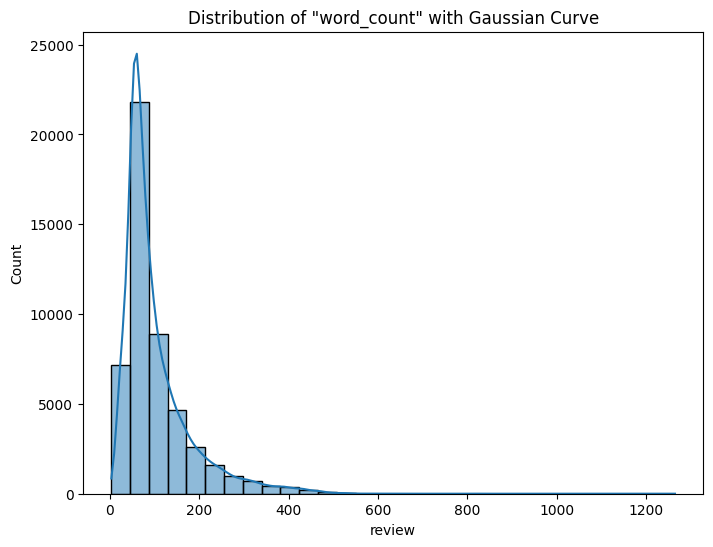

In [74]:
# Histogram with Gaussian Distribution
plt.figure(figsize=(8, 6))
sns.histplot(word_count, kde=True, bins=30)
plt.title(f'Distribution of "word_count" with Gaussian Curve')
plt.show()

## 5.1.2 Measures of Data Dispersion

#### Quartiles and outliers detection

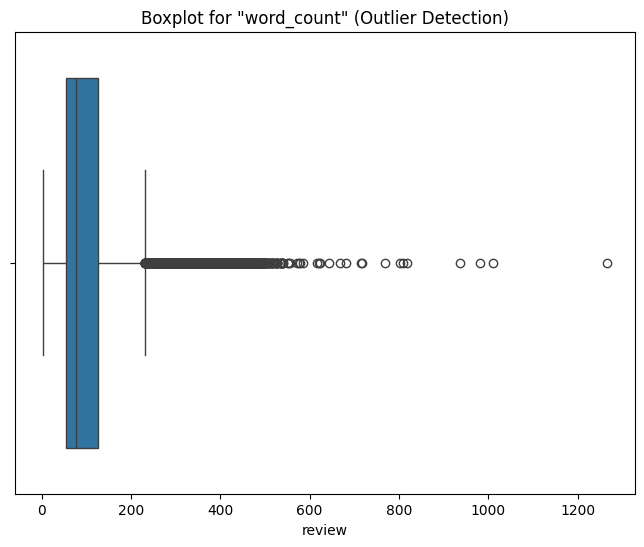

In [75]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=word_count)
plt.title(f'Boxplot for "word_count" (Outlier Detection)')
plt.show()

#### Quantiles

In [76]:
word_count_quartiles = word_count.quantile([0.25, 0.5, 0.75])
print(f"\nQuartiles:\n{word_count_quartiles}")


Quartiles:
0.25     54.0
0.50     76.0
0.75    125.0
Name: review, dtype: float64


###### Variance and standard deviation

In [77]:
word_count_variance = word_count.var()
word_count_std_dev = word_count.std()
print(f"Variance: {word_count_variance:.2f}")
print(f"Standard Deviation: {word_count_std_dev:.2f}")

Variance: 6202.37
Standard Deviation: 78.76


## 5.1.3. Per Sentiments statistics

In [78]:
# Separate positive and negative reviews
positive_reviews = ' '.join(clean_imdb_df[clean_imdb_df['sentiment'] == 'positive']['review'])
negative_reviews = ' '.join(clean_imdb_df[clean_imdb_df['sentiment'] == 'negative']['review'])

##### Word cloud

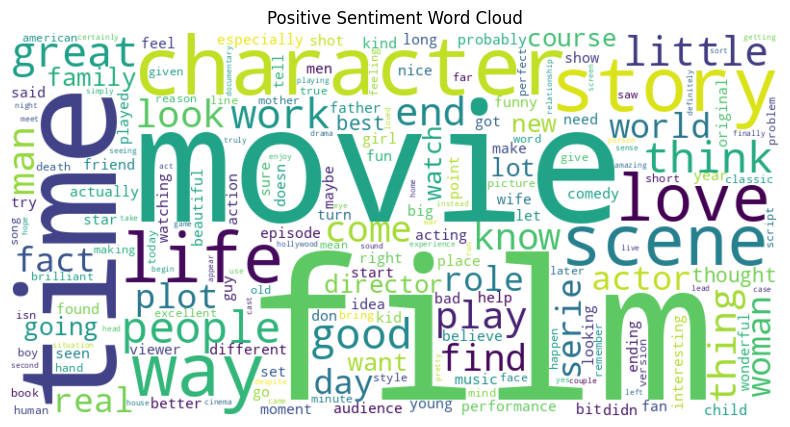

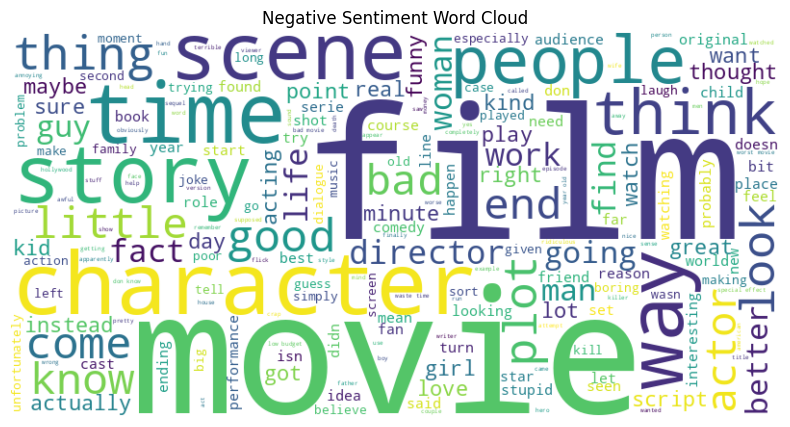

In [79]:
# Function to generate word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds
generate_word_cloud(positive_reviews, 'Positive Sentiment Word Cloud')
print()

generate_word_cloud(negative_reviews, 'Negative Sentiment Word Cloud')

##### Top 15 words per sentiment

In [80]:
# Function to get top n words
def get_top_n_words(review, n=10):
    words = review.split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

# Get top 10 words
top_10_positive = get_top_n_words(positive_reviews)
top_10_negative = get_top_n_words(negative_reviews)

print("Top 10 words in positive sentiment:")
display(top_10_positive)
print()

print("Top 10 words in negative sentiment:")
display(top_10_negative)
print()


Top 10 words in positive sentiment:


[('film', 49530),
 ('movie', 44623),
 ('like', 18124),
 ('time', 16243),
 ('good', 15030),
 ('story', 14142),
 ('character', 13957),
 ('great', 12934),
 ('scene', 10018),
 ('life', 9857)]


Top 10 words in negative sentiment:


[('movie', 57836),
 ('film', 43249),
 ('like', 22652),
 ('time', 14950),
 ('good', 14616),
 ('bad', 14551),
 ('character', 14152),
 ('scene', 11262),
 ('story', 10957),
 ('don', 10505)]

##### Average word counts per sentiment

In [81]:
# Function to calculate average review length and word count
def calculate_averages(df, sentiment):
    sentiment_df = df[df['sentiment'] == sentiment]
    avg_word_count = sentiment_df['review'].apply(lambda x: len(x.split())).mean()
    return avg_word_count


# Calculate averages
avg_word_count_positive = calculate_averages(clean_imdb_df, 'positive')
avg_word_count_negative = calculate_averages(clean_imdb_df, 'negative')


print(f"Average word count of a review for positive sentiment: {avg_word_count_positive:.2f}")
print(f"Average word count of a review for negative sentiment: {avg_word_count_negative:.2f}")

Average word count of a review for positive sentiment: 104.71
Average word count of a review for negative sentiment: 100.71


# 5.2. review length statistics

In [82]:
# Calculate word review length statistics
review_length = clean_imdb_df['review'].apply(len)

## 5.2.1 Measures of Central Tendency

##### mean:

In [84]:
review_length_mean = review_length.mean()
print(f"Mean: {review_length_mean:.2f}")

Mean: 715.00


##### median

In [85]:
review_length_median = review_length.median()
print(f"Median: {review_length_median:.2f}")

Median: 523.00


##### mode

In [86]:
review_length_mode = review_length.mode()[0]
print(f"Mode: {review_length_mode:.2f}")

Mode: 362.00


##### max

In [87]:
review_length_max_value = review_length.max()
print(f"Max: {review_length_max_value:.2f}")

Max: 8432.00


##### min

In [88]:
review_length_min_value = review_length.min()
print(f"Min: {review_length_min_value:.2f}")

Min: 17.00


##### Gaussian distribution

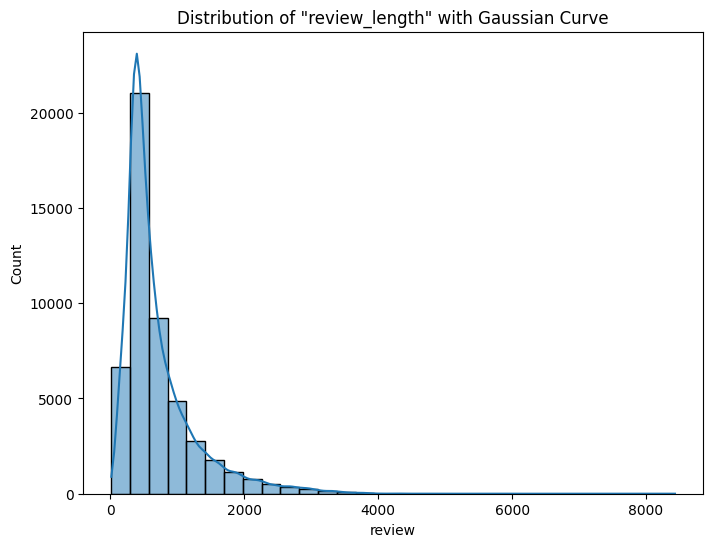

In [89]:
# Histogram with Gaussian Distribution
plt.figure(figsize=(8, 6))
sns.histplot(review_length, kde=True, bins=30)
plt.title(f'Distribution of "review_length" with Gaussian Curve')
plt.show()

## 5.2.2 Measures of Data Dispersion

#### Quartiles and outliers detection

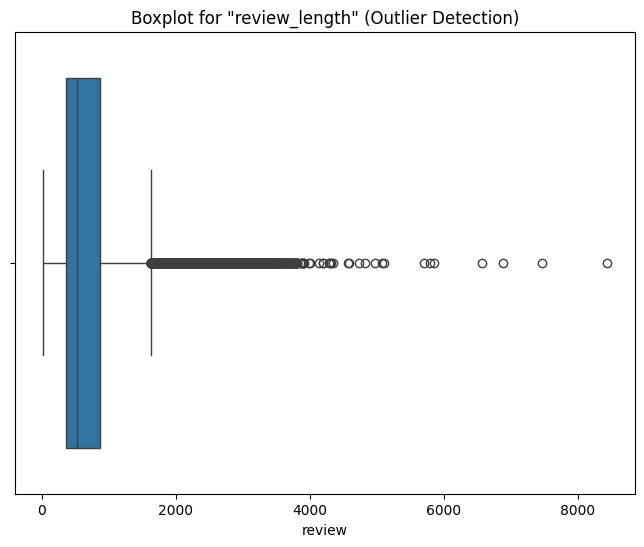

In [90]:
# Outlier Detection using Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=review_length)
plt.title(f'Boxplot for "review_length" (Outlier Detection)')
plt.show()

#### Quantiles

In [91]:
review_length_quartiles = review_length.quantile([0.25, 0.5, 0.75])
print(f"\nQuartiles:\n{review_length_quartiles}")


Quartiles:
0.25    367.0
0.50    523.0
0.75    872.0
Name: review, dtype: float64


###### Variance and standard deviation

In [92]:
review_length_variance = review_length.var()
review_length_std_dev = review_length.std()
print(f"Variance: {review_length_variance:.2f}")
print(f"Standard Deviation: {review_length_std_dev:.2f}")

Variance: 315726.11
Standard Deviation: 561.90


## 5.2.3. Per Sentiments statistics

In [93]:
# Separate positive and negative reviews
positive_reviews = ' '.join(clean_imdb_df[clean_imdb_df['sentiment'] == 'positive']['review'])
negative_reviews = ' '.join(clean_imdb_df[clean_imdb_df['sentiment'] == 'negative']['review'])

##### Average review length per sentiment

In [94]:
# Function to calculate average review length and word count
def calculate_averages(df, sentiment):
    sentiment_df = df[df['sentiment'] == sentiment]
    avg_review_length = sentiment_df['review'].apply(len).mean()
    return avg_review_length


# Calculate averages
avg_review_length_positive = calculate_averages(clean_imdb_df, 'positive')
avg_review_length_negative = calculate_averages(clean_imdb_df, 'negative')


print(f"Average word count of a review for positive sentiment: {avg_review_length_positive:.2f}")
print(f"Average word count of a review for negative sentiment: {avg_review_length_negative:.2f}")

Average word count of a review for positive sentiment: 734.46
Average word count of a review for negative sentiment: 695.39


# 6. Feature engineering

## 6.1. Label encoding

In [97]:
label_encoder = LabelEncoder()
clean_imdb_df['sentiment_encoded'] = label_encoder.fit_transform(clean_imdb_df['sentiment'])
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'negative': 0, 'positive': 1}


## 6.2. Train-test split

In [98]:
X = clean_imdb_df['review']
y = clean_imdb_df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print()
print("Testing samples:", X_test.shape[0])

Training samples: 39665

Testing samples: 9917


## 6.3. TF-IDF

In [99]:
# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.9)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

feature_names = tfidf_vectorizer.get_feature_names_out()


In [100]:

# Display TF-IDF features
print("Sample TF-IDF features for first document:")
sample_idx = 0
sample_features = X_train_tfidf[sample_idx].toarray()[0]
sample_words = [(word, score) for word, score in zip(feature_names, sample_features) if score > 0]
sample_words.sort(key=lambda x: x[1], reverse=True)

for word, score in sample_words[:10]:
    print(f"{word}: {score:.4f}")

Sample TF-IDF features for first document:
blood: 0.5905
witness: 0.3796
refuse: 0.2657
issue: 0.2120
die: 0.2054
seen: 0.1727
allowing: 0.1435
medical: 0.1404
patient: 0.1316
statement: 0.1300


## 6.4. BOW (Bag-Of-Words)

In [103]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [104]:
# Display Bow features
print("Sample Bow features for first document:")
sample_idx = 0
sample_features = X_train_bow[sample_idx].toarray()[0]
sample_words = [(word, score) for word, score in zip(feature_names, sample_features) if score > 0]
sample_words.sort(key=lambda x: x[1], reverse=True)

for word, score in sample_words[:10]:
    print(f"{word}: {score:.4f}")

Sample Bow features for first document:
bob: 6.0000
section: 3.0000
worked: 3.0000
don wrong: 2.0000
joel: 2.0000
reasonable: 2.0000
yesterday: 2.0000
actor: 1.0000
allen: 1.0000
amazing: 1.0000


## 6.5. Embeddings

# 7. Models